# 70 — LSEG/Gemma continuous joined long-window replay

**Question.** Does Notebook 39's cross-model-portable continuous Gemma
construction retain after-cost economic value when the model, Reuters source,
33-company universe, portfolio rule, and accounting are held fixed through the
earlier and already-opened LSEG periods?

**Frozen before this result.** The source-controlled specification fixes the
mean-continuous reducer, q90-q10 dispersion state, trailing-60 q75 gate after
40 complete observations, top-two/bottom-two breadth, 25% weights, one-session
horizon, 10-bps primary cost, two cash comparisons, and the 2025-10-26 boundary.

**Evidence status.** This is a bounded retrospective temporal stress test. The
LSEG returns and related strategy outcomes were already opened. No result here
is independent confirmation, validated alpha, or permission to retune.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import build_aggregation_panel  # noqa: E402
from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.joined_lseg import (  # noqa: E402
    JOIN_BOUNDARY,
    JoinedLsegInputs,
    load_joined_same33_scores,
)
from final_experiments.lib.lseg_expanded import (  # noqa: E402
    canonical_score_frame,
    load_price_exports,
    map_headlines_to_entry_sessions,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    annotate_source,
    apply_house_style,
    zero_line,
)
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import ledger_rows_to_frame  # noqa: E402
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PositionTarget,
    TargetPortfolio,
)
from sentiment_benchmark.trading_effectiveness import benjamini_hochberg  # noqa: E402

SEED = 20260821
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
BOOTSTRAP_REPLICATIONS = 9_999
TRAILING_SESSIONS = 60
MIN_TRAILING_SESSIONS = 40
EVENT_INTENSITY_QUANTILE = 0.75
TOP_BOTTOM_NAMES = 2
SINGLE_NAME_CAP = 0.25
INITIAL_NAV = 1_000_000.0
MIN_ACTIVE_PER_BLOCK = 15

sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
original_symbols = tuple(symbol for members in sector_members.values() for symbol in members)
SYMBOLS = tuple(sorted(original_symbols))
boundary = JOIN_BOUNDARY.tz_localize(None)

BACKWARD_DERIVED = (
    REPO_ROOT
    / "Data/collections/lseg_us_sector_33_backward_20240101_20251026_headlines/derived"
)
SNAPSHOT = "snapshot_20260811_collection_complete"
INPUTS = JoinedLsegInputs(
    backward_finbert=(
        BACKWARD_DERIVED
        / "incremental_finbert"
        / SNAPSHOT
        / "headline_scores_finbert4556_cacheonly.csv"
    ),
    backward_gemma_seed=(
        BACKWARD_DERIVED
        / "incremental_gemma"
        / SNAPSHOT
        / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1_resume_seed.csv"
    ),
    backward_gemma_delta=(
        BACKWARD_DERIVED
        / "incremental_gemma"
        / SNAPSHOT
        / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1_delta.csv"
    ),
    recent_finbert=(
        REPO_ROOT
        / "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_finbert4556_cacheonly_20260803.csv"
    ),
    recent_gemma=(
        REPO_ROOT
        / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
        / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
    ),
)
SPEC_PATH = REPO_ROOT / "final_experiments/frozen_specs/lseg_gemma_continuous_joined_long_window_v1_20260812.json"
NOTEBOOK39_MANIFEST = REPO_ROOT / "final_experiments/outputs/39_gemma_continuous_portability/manifest.json"
NOTEBOOK67_MANIFEST = REPO_ROOT / "final_experiments/outputs/67_lseg_gemma_finbert_joined_long_window/manifest.json"
PRICE_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_2024_2026.csv"
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/70_lseg_gemma_continuous_joined_long_window"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

apply_house_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Freeze binding and duplicate-score reproducibility

This section never parses a price value or return. It validates the frozen
manifests, reloads the paired scorer populations, and measures how the same
headline's cached score changed when it appeared in both acquisition blocks.

In [2]:
spec = json.loads(SPEC_PATH.read_text(encoding="utf-8"))
notebook39 = json.loads(NOTEBOOK39_MANIFEST.read_text(encoding="utf-8"))
notebook67 = json.loads(NOTEBOOK67_MANIFEST.read_text(encoding="utf-8"))

for binding, path in (
    (spec["inputs"]["notebook_39_manifest"], NOTEBOOK39_MANIFEST),
    (spec["inputs"]["notebook_67_manifest"], NOTEBOOK67_MANIFEST),
):
    if sha256_file(path) != binding["sha256"]:
        raise ValueError(f"frozen manifest hash changed: {path}")
if sha256_file(PRICE_PATH) != spec["inputs"]["price_panel"]["sha256"]:
    raise ValueError("frozen price-panel hash changed")

expected_notebook39 = {
    "firm_open_reducer": "mean_continuous",
    "long_names": TOP_BOTTOM_NAMES,
    "short_names": TOP_BOTTOM_NAMES,
    "single_name_cap": SINGLE_NAME_CAP,
    "gross_exposure": 1.0,
    "holding_intervals": 1,
    "cost_bps_per_side_for_future_test": COST_BPS,
    "current_return_window_evaluated": False,
}
for key, expected in expected_notebook39.items():
    if notebook39["selected_future_specification"].get(key) != expected:
        raise ValueError(f"Notebook 39 specification mismatch for {key}")
if notebook39["adaptive_schedule"] != {
    "top_bottom_names": TOP_BOTTOM_NAMES,
    "trailing_sessions": TRAILING_SESSIONS,
    "minimum_trailing_sessions": MIN_TRAILING_SESSIONS,
    "event_intensity_quantile": EVENT_INTENSITY_QUANTILE,
}:
    raise ValueError("Notebook 39 adaptive schedule changed")
if notebook67["join"]["joined_population_sha256"] != spec["inputs"]["joined_population_sha256"]:
    raise ValueError("Notebook 67 joined population changed")
if notebook67["join"]["joined_unique_headlines"] != spec["inputs"]["joined_unique_headlines"]:
    raise ValueError("Notebook 67 joined population count changed")

populations, score_audit = load_joined_same33_scores(INPUTS, original_symbols=original_symbols)
population_summary = pd.DataFrame(
    [
        {
            "population": name,
            "unique_headlines": len(frame),
            "first_timestamp": frame["first_timestamp"].min(),
            "last_timestamp": frame["first_timestamp"].max(),
        }
        for name, frame in populations.items()
    ]
)

overlap = populations["backward"][["headline_sha256", "score_gemma", "score_finbert"]].merge(
    populations["recent"][["headline_sha256", "score_gemma", "score_finbert"]],
    on="headline_sha256",
    how="inner",
    suffixes=("_backward", "_recent"),
    validate="one_to_one",
)
if len(overlap) != spec["inputs"]["cross_block_overlap_hashes"]:
    raise RuntimeError("cross-block overlap count changed")

duplicate_rows = []
for scorer in ("gemma", "finbert"):
    left = overlap[f"score_{scorer}_backward"].to_numpy(dtype=float)
    right = overlap[f"score_{scorer}_recent"].to_numpy(dtype=float)
    absolute = np.abs(left - right)
    duplicate_rows.append(
        {
            "scorer": scorer,
            "matched_hashes": len(overlap),
            "spearman": float(pd.Series(left).corr(pd.Series(right), method="spearman")),
            "pearson": float(np.corrcoef(left, right)[0, 1]),
            "sign_agreement": float(np.mean(np.sign(left) == np.sign(right))),
            "exact_equality": float(np.mean(left == right)),
            "different_above_1e_12": int(np.sum(absolute > 1e-12)),
            "mean_absolute_difference": float(absolute.mean()),
            "median_absolute_difference": float(np.median(absolute)),
            "p95_absolute_difference": float(np.quantile(absolute, 0.95)),
            "maximum_absolute_difference": float(absolute.max()),
        }
    )
duplicate_reproducibility = pd.DataFrame(duplicate_rows)
display(population_summary)
display(duplicate_reproducibility)
print("Price values or returns loaded:", False)

,population,unique_headlines,first_timestamp,last_timestamp
0,backward,1219608,2024-01-01 00:00:00+00:00,2025-10-25 23:59:08.689000+00:00
1,recent,764390,2025-10-26 00:01:06.326000+00:00,2026-06-25 23:58:46+00:00
2,joined,1967554,2024-01-01 00:00:00+00:00,2026-06-25 23:58:46+00:00


,scorer,matched_hashes,spearman,pearson,sign_agreement,exact_equality,different_above_1e_12,mean_absolute_difference,median_absolute_difference,p95_absolute_difference,maximum_absolute_difference
0,gemma,16444,0.989282,0.993619,0.981331,0.884578,1757,0.012127,0.000000,0.100000,1.400000
1,finbert,16444,0.998200,0.998507,0.999088,0.204391,13083,0.001643,0.000000,0.000002,1.025242


Price values or returns loaded: False


## Return-free joined firm-open panel and continuous schedule

The price export contributes only the 33-company session calendar here. The
joined score population is collapsed to mean signed Gemma score at firm-open.
The dispersion state is computed once through the full history. Incomplete
acquisition sessions remain on the clock as cash and do not enter the trailing
spread history.

In [3]:
calendar = pd.read_csv(PRICE_PATH, usecols=["symbol", "session_date"])
calendar["symbol"] = calendar["symbol"].astype(str)
calendar["session_date"] = pd.to_datetime(calendar["session_date"]).dt.normalize()
calendar = calendar.loc[calendar["symbol"].isin(SYMBOLS)].copy()
if calendar.duplicated(["symbol", "session_date"]).any():
    raise ValueError("price calendar contains duplicate symbol-session rows")

joined_scores = canonical_score_frame(populations["joined"], scorer="gemma")
events = map_headlines_to_entry_sessions(joined_scores, calendar)
events = events.loc[events["symbol"].isin(SYMBOLS)].copy()
keys = events[["symbol", "entry_session"]].drop_duplicates().rename(
    columns={"entry_session": "session_date"}
)
keys["split"] = "retrospective_joined_lseg"
firm_open = build_aggregation_panel(keys, stories=events)
firm_open["session_date"] = pd.to_datetime(firm_open["session_date"]).dt.normalize()
firm_open = firm_open.sort_values(["session_date", "symbol"], kind="mergesort").reset_index(drop=True)
if firm_open["mean_continuous"].isna().any():
    raise RuntimeError("joined firm-open panel contains a missing continuous score")

common_sessions = (
    calendar.groupby("session_date")["symbol"]
    .nunique()
    .loc[lambda value: value.eq(len(SYMBOLS))]
    .index.sort_values()
)
signal_start = firm_open["session_date"].min()
signal_end = firm_open["session_date"].max()
sessions = pd.DatetimeIndex(
    common_sessions[(common_sessions >= signal_start) & (common_sessions <= signal_end)]
)
expected_joined_sessions = int(
    next(row["n_sessions"] for row in notebook67["results"] if row["window"] == "joined_2024_2026")
)
if len(sessions) != expected_joined_sessions:
    raise RuntimeError(f"joined session clock changed: {len(sessions)} != {expected_joined_sessions}")

firm_counts = firm_open.groupby("session_date")["symbol"].nunique().reindex(sessions, fill_value=0)
complete = firm_counts.eq(len(SYMBOLS))
incomplete_sessions = sessions[~complete.to_numpy()]
if len(incomplete_sessions) != 11 or (incomplete_sessions >= boundary).any():
    raise RuntimeError("frozen incomplete-session pattern changed")

complete_panel = firm_open.loc[firm_open["session_date"].isin(sessions[complete.to_numpy()])].copy()
spread = complete_panel.groupby("session_date")["mean_continuous"].apply(
    lambda values: float(values.quantile(0.90) - values.quantile(0.10))
).sort_index()
threshold = spread.shift(1).rolling(
    TRAILING_SESSIONS,
    min_periods=MIN_TRAILING_SESSIONS,
).quantile(EVENT_INTENSITY_QUANTILE)

schedule = pd.DataFrame({"session_date": sessions})
schedule["complete_session"] = schedule["session_date"].map(complete).fillna(False).astype(bool)
schedule["dispersion"] = schedule["session_date"].map(spread)
schedule["trailing_threshold"] = schedule["session_date"].map(threshold)
schedule["active"] = (
    schedule["complete_session"]
    & schedule["trailing_threshold"].notna()
    & schedule["dispersion"].ge(schedule["trailing_threshold"])
)

weights = np.zeros((len(sessions), len(SYMBOLS)), dtype=float)
long_values: list[str] = []
short_values: list[str] = []
for row_number, row in schedule.iterrows():
    if not bool(row["active"]):
        long_values.append("")
        short_values.append("")
        continue
    day = (
        firm_open.loc[
            firm_open["session_date"].eq(row["session_date"]),
            ["symbol", "mean_continuous"],
        ]
        .set_index("symbol")
        .reindex(SYMBOLS)
    )
    if day["mean_continuous"].isna().any():
        raise RuntimeError("active complete session contains a missing score")
    ordered = day.reset_index().sort_values(["mean_continuous", "symbol"], kind="mergesort")
    short_symbols = tuple(ordered.head(TOP_BOTTOM_NAMES)["symbol"])
    long_symbols = tuple(ordered.tail(TOP_BOTTOM_NAMES)["symbol"])
    if set(long_symbols) & set(short_symbols):
        raise RuntimeError("continuous rank legs overlap")
    long_indices = [SYMBOLS.index(symbol) for symbol in long_symbols]
    short_indices = [SYMBOLS.index(symbol) for symbol in short_symbols]
    weights[row_number, long_indices] = 0.5 / TOP_BOTTOM_NAMES
    weights[row_number, short_indices] = -0.5 / TOP_BOTTOM_NAMES
    long_values.append("|".join(sorted(long_symbols)))
    short_values.append("|".join(sorted(short_symbols)))

schedule["long_symbols"] = long_values
schedule["short_symbols"] = short_values
if np.abs(weights).max() > SINGLE_NAME_CAP + 1e-12:
    raise RuntimeError("frozen continuous target violates the single-name cap")
if not np.allclose(weights.sum(axis=1), 0.0, atol=1e-12):
    raise RuntimeError("frozen continuous targets are not dollar neutral")

block_masks = {
    "backward_2024_2025": schedule["session_date"].lt(boundary).to_numpy(),
    "opened_2025_2026": schedule["session_date"].ge(boundary).to_numpy(),
    "joined_2024_2026": np.ones(len(schedule), dtype=bool),
}
input_summary = pd.DataFrame(
    [
        {
            "window": name,
            "sessions": int(mask.sum()),
            "complete_sessions": int((schedule["complete_session"].to_numpy() & mask).sum()),
            "incomplete_cash_sessions": int((~schedule["complete_session"].to_numpy() & mask).sum()),
            "active_sessions": int((schedule["active"].to_numpy() & mask).sum()),
            "first_session": schedule.loc[mask, "session_date"].min(),
            "last_session": schedule.loc[mask, "session_date"].max(),
        }
        for name, mask in block_masks.items()
    ]
)
input_gate = bool(
    input_summary.loc[
        input_summary["window"].isin(["backward_2024_2025", "opened_2025_2026"]),
        "active_sessions",
    ].ge(MIN_ACTIVE_PER_BLOCK).all()
)
display(input_summary)
print("Return-free active-session gate:", input_gate)
if not input_gate:
    raise RuntimeError("continuous long-window replay stopped at the return-free activity gate")

del joined_scores, events, populations
print("Price values or returns loaded:", False)

,window,sessions,complete_sessions,incomplete_cash_sessions,active_sessions,first_session,last_session
0,backward_2024_2025,456,445,11,113,2024-01-02,2025-10-24
1,opened_2025_2026,167,167,0,44,2025-10-27,2026-06-26
2,joined_2024_2026,623,612,11,157,2024-01-02,2026-06-26


Return-free active-session gate: True
Price values or returns loaded: False


## Open-to-next-open returns and accounting validation

Only after the frozen input gate passes do numeric adjusted opens enter the
notebook. Each source block is backtested independently from cash and charged
its own entry and terminal liquidation. The full joined path is descriptive.

In [4]:
prices = load_price_exports(PRICE_PATH, expected_symbols=33)
open_wide = (
    prices.pivot(index="session_date", columns="symbol", values="adjusted_open")
    .sort_index()
    .reindex(columns=SYMBOLS)
    .dropna()
)
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise RuntimeError("signal sessions are not consecutive on the common 33-company price clock")
if locations[-1] + 1 >= len(open_wide):
    raise RuntimeError("last signal session lacks a following common open")
next_sessions = pd.DatetimeIndex(open_wide.index[locations + 1])
return_matrix = (
    open_wide.iloc[locations + 1].to_numpy(dtype=float)
    / open_wide.iloc[locations].to_numpy(dtype=float)
    - 1.0
)
if not np.isfinite(return_matrix).all():
    raise RuntimeError("common-price return matrix contains a non-finite value")


def matrix_backtest(
    period_sessions: pd.DatetimeIndex,
    period_next_sessions: pd.DatetimeIndex,
    period_weights: np.ndarray,
    period_returns: np.ndarray,
    *,
    cost_bps: float,
) -> pd.DataFrame:
    if period_weights.shape != period_returns.shape or len(period_sessions) != len(period_weights):
        raise ValueError("matrix backtest inputs do not align")
    current = np.zeros(period_weights.shape[1], dtype=float)
    rate = cost_bps / 10_000.0
    rows = []
    for session, next_session, target, asset_returns in zip(
        period_sessions,
        period_next_sessions,
        period_weights,
        period_returns,
        strict=True,
    ):
        turnover = float(np.abs(target - current).sum())
        cost = rate * turnover
        gross = float(np.dot(target, asset_returns))
        net = gross - cost
        if 1.0 + net <= 0:
            raise RuntimeError("strategy NAV became non-positive")
        current = target * (1.0 + asset_returns) / (1.0 + net)
        rows.append(
            {
                "session_date": session,
                "return_end_date": next_session,
                "gross_return": gross,
                "net_return": net,
                "turnover": turnover,
                "cost": cost,
                "gross_exposure": float(np.abs(target).sum()),
                "active_names": int(np.count_nonzero(target)),
            }
        )
    liquidation_turnover = float(np.abs(current).sum())
    liquidation_cost = rate * liquidation_turnover
    rows[-1]["net_return"] = (1.0 + rows[-1]["net_return"]) * (1.0 - liquidation_cost) - 1.0
    rows[-1]["turnover"] += liquidation_turnover
    rows[-1]["cost"] += liquidation_cost
    return pd.DataFrame(rows)


def summarize(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": len(daily),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "total_return_gross": float(np.prod(1.0 + gross) - 1.0),
        "total_return_net": float(equity[-1] - 1.0),
        "max_drawdown": float(np.min(with_start / np.maximum.accumulate(with_start) - 1.0)),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),
        "cost_bps_per_side": cost_bps,
    }


def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected exactly one terminal liquidation")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    return intervals


def matrix_to_targets(period_sessions: pd.DatetimeIndex, period_weights: np.ndarray) -> tuple[TargetPortfolio, ...]:
    targets = []
    for session, vector in zip(period_sessions, period_weights, strict=True):
        nonzero = np.flatnonzero(~np.isclose(vector, 0.0))
        positions = tuple(
            PositionTarget(
                symbol=SYMBOLS[index],
                action=float(np.sign(vector[index])),
                volatility=None,
                raw_weight=float(vector[index]),
                target_weight=float(vector[index]),
                exclusion_reason=None,
            )
            for index in nonzero
        )
        long_exposure = float(vector[vector > 0].sum())
        short_exposure = float(-vector[vector < 0].sum())
        targets.append(
            TargetPortfolio(
                session=str(pd.Timestamp(session).date()),
                positions=positions,
                gross_exposure=long_exposure + short_exposure,
                net_exposure=long_exposure - short_exposure,
                long_exposure=long_exposure,
                short_exposure=short_exposure,
                cash_weight=1.0 - (long_exposure - short_exposure),
            )
        )
    return tuple(targets)


def matrix_to_returns(
    period_sessions: pd.DatetimeIndex,
    period_next_sessions: pd.DatetimeIndex,
    period_weights: np.ndarray,
    period_returns: np.ndarray,
) -> list[OpenToOpenReturn]:
    rows = []
    for session, next_session, vector, asset_returns in zip(
        period_sessions,
        period_next_sessions,
        period_weights,
        period_returns,
        strict=True,
    ):
        rows.append(
            OpenToOpenReturn(
                symbol="__CLOCK__",
                session=str(pd.Timestamp(session).date()),
                next_session=str(pd.Timestamp(next_session).date()),
                value=0.0,
            )
        )
        for index in np.flatnonzero(~np.isclose(vector, 0.0)):
            rows.append(
                OpenToOpenReturn(
                    symbol=SYMBOLS[index],
                    session=str(pd.Timestamp(session).date()),
                    next_session=str(pd.Timestamp(next_session).date()),
                    value=float(asset_returns[index]),
                )
            )
    return rows


period_indices = {name: np.flatnonzero(mask) for name, mask in block_masks.items()}


def run_period(name: str, *, cost_bps: float) -> pd.DataFrame:
    indices = period_indices[name]
    return matrix_backtest(
        sessions[indices],
        next_sessions[indices],
        weights[indices],
        return_matrix[indices],
        cost_bps=cost_bps,
    )


daily_paths = {name: run_period(name, cost_bps=COST_BPS) for name in period_indices}
strategy_results = pd.DataFrame(
    [
        {"window": name, **summarize(daily, cost_bps=COST_BPS)}
        for name, daily in daily_paths.items()
    ]
)

accounting_rows = []
for name, daily in daily_paths.items():
    indices = period_indices[name]
    ledger = ledger_rows_to_frame(
        run_open_to_open_ledger(
            matrix_to_targets(sessions[indices], weights[indices]),
            matrix_to_returns(
                sessions[indices],
                next_sessions[indices],
                weights[indices],
                return_matrix[indices],
            ),
            cost_rate_per_side=COST_BPS / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    ledger = fold_final_liquidation(ledger)
    errors = {
        column: float((ledger[column] - daily[column]).abs().max())
        for column in ("gross_return", "net_return", "turnover")
    }
    if max(errors.values()) > 1e-12:
        raise RuntimeError(f"{name} matrix accounting disagrees with the ledger: {errors}")
    accounting_rows.append({"window": name, **errors})
accounting_audit = pd.DataFrame(accounting_rows)
display(strategy_results)
display(accounting_audit)

,window,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,backward_2024_2025,456,113,0.000092,-0.000350,0.308156,-1.159397,0.037719,-0.151994,-0.171006,0.442528,201.792762,2.090037,10.000000
1,opened_2025_2026,167,44,-0.000654,-0.001120,-1.408650,-2.391363,-0.107539,-0.174504,-0.185143,0.466182,77.852339,-14.023796,10.000000
2,joined_2024_2026,623,157,-0.000108,-0.000556,-0.305645,-1.569536,-0.073877,-0.299975,-0.305931,0.448869,279.645101,-2.396005,10.000000


,window,gross_return,net_return,turnover
0,backward_2024_2025,0.000000,0.000000,0.000000
1,opened_2025_2026,0.000000,0.000000,0.000000
2,joined_2024_2026,0.000000,0.000000,0.000000


## Costs, cash inference, temporal halves, and factor controls

The two source blocks form the declared primary cash-comparison family. They
remain separate throughout; the full joined path is never treated as an
independent test or pooled with FNSPID.

In [5]:
cost_rows = []
for name in period_indices:
    for cost in COST_GRID:
        daily = run_period(name, cost_bps=cost)
        cost_rows.append({"window": name, **summarize(daily, cost_bps=cost)})
cost_curve = pd.DataFrame(cost_rows)

cash_rows = []
primary_windows = ("backward_2024_2025", "opened_2025_2026")
for offset, name in enumerate(primary_windows):
    daily = daily_paths[name]
    cash = daily[["session_date"]].copy()
    cash["net_return"] = 0.0
    cash_rows.append(
        {
            "window": name,
            **paired_block_bootstrap_difference(
                daily,
                cash,
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=BOOTSTRAP_REPLICATIONS,
                seed=SEED + offset,
            ),
        }
    )
cash_inference = pd.DataFrame(cash_rows)
cash_inference["q_bh"] = benjamini_hochberg(cash_inference["p_two_sided"].tolist())
cash_inference["multiplicity_family"] = "two source-block net-minus-cash tests; BH-FDR q=0.05"

half_rows = []
for name in primary_windows:
    indices = period_indices[name]
    midpoint = len(indices) // 2
    for half, subindices in (
        ("first_half", indices[:midpoint]),
        ("second_half", indices[midpoint:]),
    ):
        daily = matrix_backtest(
            sessions[subindices],
            next_sessions[subindices],
            weights[subindices],
            return_matrix[subindices],
            cost_bps=COST_BPS,
        )
        half_rows.append({"window": name, "period": half, **summarize(daily, cost_bps=COST_BPS)})
temporal_halves = pd.DataFrame(half_rows)

symbol_index = {symbol: index for index, symbol in enumerate(SYMBOLS)}


def factor_models(name: str) -> pd.DataFrame:
    indices = period_indices[name]
    daily = daily_paths[name]
    asset_returns = return_matrix[indices]
    factors = pd.DataFrame({"session_date": sessions[indices]})
    factors["equal_weight_market"] = asset_returns.mean(axis=1)
    for sector, members in sorted(sector_members.items()):
        columns = [symbol_index[symbol] for symbol in members]
        factors[f"sector_{sector}"] = asset_returns[:, columns].mean(axis=1)
    spreads = []
    for sector in sorted(sector_members)[:-1]:
        column = f"spread_{sector}"
        factors[column] = factors[f"sector_{sector}"] - factors["equal_weight_market"]
        spreads.append(column)
    regression = daily[["session_date", "net_return"]].merge(
        factors,
        on="session_date",
        validate="one_to_one",
    )
    rows = []
    for model, columns in {
        "constant_only": [],
        "market_only": ["equal_weight_market"],
        "sector_spanning": ["equal_weight_market", *spreads],
    }.items():
        design = sm.add_constant(regression[columns], has_constant="add")
        if np.linalg.matrix_rank(design.to_numpy(dtype=float)) != design.shape[1]:
            raise RuntimeError(f"rank-deficient factor model: {name}/{model}")
        fit = sm.OLS(regression["net_return"], design).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": BLOCK_LENGTH, "use_correction": True},
        )
        interval = fit.conf_int(alpha=0.05).loc["const"]
        rows.append(
            {
                "window": name,
                "model": model,
                "n_sessions": int(fit.nobs),
                "alpha_bps_session": float(fit.params["const"] * 10_000),
                "alpha_ci_low_bps_session": float(interval.iloc[0] * 10_000),
                "alpha_ci_high_bps_session": float(interval.iloc[1] * 10_000),
                "alpha_p_two_sided_hac5": float(fit.pvalues["const"]),
                "market_beta": float(fit.params.get("equal_weight_market", np.nan)),
                "r_squared": float(fit.rsquared),
            }
        )
    return pd.DataFrame(rows)


factor_results = pd.concat([factor_models(name) for name in primary_windows], ignore_index=True)

result_lookup = strategy_results.set_index("window")
cash_lookup = cash_inference.set_index("window")
block_gate_rows = []
for name in primary_windows:
    result = result_lookup.loc[name]
    cash = cash_lookup.loc[name]
    halves = temporal_halves.loc[temporal_halves["window"].eq(name)]
    input_row = input_summary.set_index("window").loc[name]
    input_ok = bool(input_row["active_sessions"] >= MIN_ACTIVE_PER_BLOCK)
    net_ok = bool(result["total_return_net"] > 0)
    breakeven_ok = bool(result["breakeven_bps_per_side"] > COST_BPS)
    cash_ok = bool(cash["ci_low"] > 0 and cash["q_bh"] < 0.05)
    halves_ok = bool(halves["sharpe_net"].gt(0).all())
    block_gate_rows.append(
        {
            "window": name,
            "input_activity_gate": input_ok,
            "positive_net_return_gate": net_ok,
            "breakeven_above_charged_cost_gate": breakeven_ok,
            "cash_interval_and_bh_gate": cash_ok,
            "positive_both_halves_gate": halves_ok,
            "economic_stability_gate": bool(input_ok and net_ok and breakeven_ok and cash_ok and halves_ok),
        }
    )
block_gates = pd.DataFrame(block_gate_rows)
cross_time_stability = bool(block_gates["economic_stability_gate"].all())
gates = pd.DataFrame(
    [
        {
            "return_free_activity_gate": input_gate,
            "backward_economic_stability_gate": bool(
                block_gates.set_index("window").loc["backward_2024_2025", "economic_stability_gate"]
            ),
            "opened_economic_stability_gate": bool(
                block_gates.set_index("window").loc["opened_2025_2026", "economic_stability_gate"]
            ),
            "cross_time_stability_gate": cross_time_stability,
            "retrospective_promotion_allowed": False,
            "prospective_or_deployment_claim": False,
        }
    ]
)
display(cost_curve)
display(cash_inference)
display(temporal_halves)
display(factor_results)
display(block_gates)
display(gates.T)

,window,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,backward_2024_2025,456,113,0.000092,0.000092,0.308156,0.308156,0.037719,0.037719,-0.067280,0.442253,201.667545,2.091335,0.000000
1,backward_2024_2025,456,113,0.000092,0.000048,0.308156,0.160813,0.037719,0.017001,-0.072868,0.442280,201.679792,2.091208,1.000000
2,backward_2024_2025,456,113,0.000092,0.000004,0.308156,0.013423,0.037719,-0.003308,-0.078424,0.442307,201.692159,2.091079,2.000000
3,backward_2024_2025,456,113,0.000092,-0.000129,0.308156,-0.428364,0.037719,-0.061863,-0.099508,0.442390,201.729614,2.090691,5.000000
4,backward_2024_2025,456,113,0.000092,-0.000350,0.308156,-1.159397,0.037719,-0.151994,-0.171006,0.442528,201.792762,2.090037,10.000000
5,opened_2025_2026,167,44,-0.000654,-0.000654,-1.408650,-1.408650,-0.107539,-0.107539,-0.132550,0.465919,77.808488,-14.031699,0.000000
6,opened_2025_2026,167,44,-0.000654,-0.000700,-1.408650,-1.508075,-0.107539,-0.114466,-0.137953,0.465945,77.812867,-14.030910,1.000000
7,opened_2025_2026,167,44,-0.000654,-0.000747,-1.408650,-1.607290,-0.107539,-0.121341,-0.143324,0.465972,77.817248,-14.030120,2.000000
8,opened_2025_2026,167,44,-0.000654,-0.000887,-1.408650,-1.903492,-0.107539,-0.141656,-0.159243,0.466050,77.830397,-14.027749,5.000000
9,opened_2025_2026,167,44,-0.000654,-0.001120,-1.408650,-2.391363,-0.107539,-0.174504,-0.185143,0.466182,77.852339,-14.023796,10.000000


,window,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,q_bh,multiplicity_family
0,backward_2024_2025,456,-0.000350,-0.000771,0.000090,0.111000,5,9999,20260821,0.111000,two source-block net-minus-cash tests; BH-FDR ...
1,opened_2025_2026,167,-0.001120,-0.002079,-0.000248,0.016500,5,9999,20260822,0.033000,two source-block net-minus-cash tests; BH-FDR ...


,window,period,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,backward_2024_2025,first_half,228,59,0.000030,-0.000449,0.113966,-1.654754,0.004915,-0.099144,-0.106809,0.479059,109.225339,0.635677,10.000000
1,backward_2024_2025,second_half,228,54,0.000155,-0.000251,0.467761,-0.761219,0.032643,-0.058667,-0.125925,0.405997,92.567423,3.806115,10.000000
2,opened_2025_2026,first_half,83,19,-0.000319,-0.000711,-0.776312,-1.713149,-0.027811,-0.059008,-0.071811,0.392432,32.571851,-8.118056,10.000000
3,opened_2025_2026,second_half,84,25,-0.000985,-0.001524,-1.918699,-2.939440,-0.082008,-0.122739,-0.122739,0.539053,45.280488,-18.272003,10.000000


,window,model,n_sessions,alpha_bps_session,alpha_ci_low_bps_session,alpha_ci_high_bps_session,alpha_p_two_sided_hac5,market_beta,r_squared
0,backward_2024_2025,constant_only,456,-3.500380,-7.835914,0.835154,0.113555,NaN,-0.000000
1,backward_2024_2025,market_only,456,-3.457980,-7.982645,1.066685,0.134158,-0.004502,0.000084
2,backward_2024_2025,sector_spanning,456,-3.730210,-8.142998,0.682578,0.097561,-0.010543,0.012575
3,opened_2025_2026,constant_only,167,-11.198582,-20.342717,-2.054447,0.016381,NaN,-0.000000
4,opened_2025_2026,market_only,167,-10.615623,-19.685060,-1.546187,0.021784,-0.079851,0.005809
5,opened_2025_2026,sector_spanning,167,-10.301668,-19.286065,-1.317271,0.024619,-0.158716,0.074316


,window,input_activity_gate,positive_net_return_gate,breakeven_above_charged_cost_gate,cash_interval_and_bh_gate,positive_both_halves_gate,economic_stability_gate
0,backward_2024_2025,True,False,False,False,False,False
1,opened_2025_2026,True,False,False,False,False,False


,0
return_free_activity_gate,True
backward_economic_stability_gate,False
opened_economic_stability_gate,False
cross_time_stability_gate,False
retrospective_promotion_allowed,False
prospective_or_deployment_claim,False


## Figures

findfont: Failed to find font weight medium, now using 400.


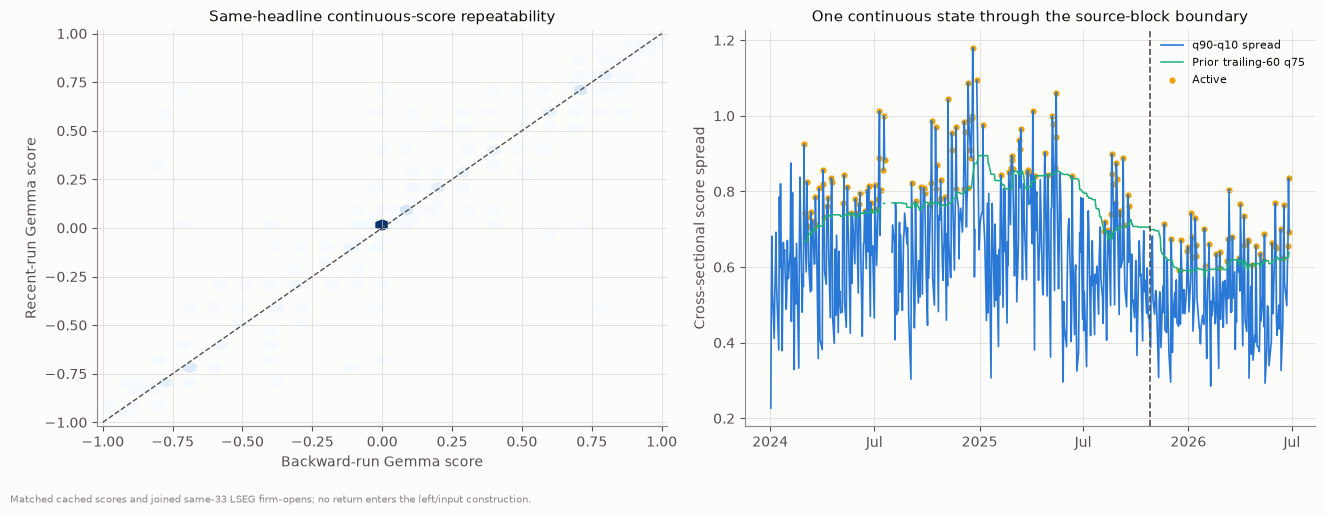

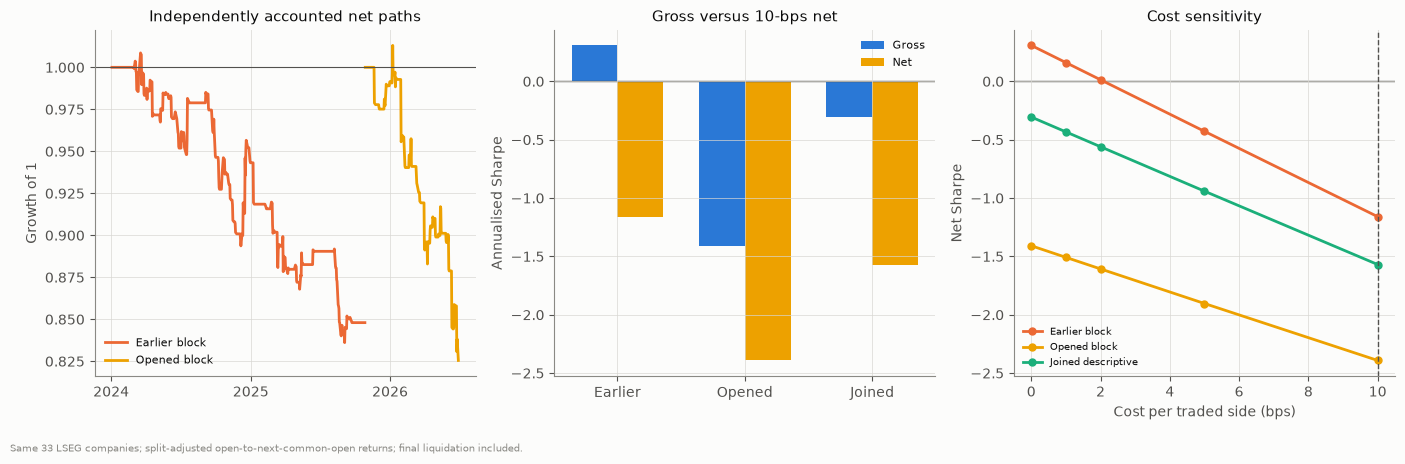

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.9))
gemma_left = overlap["score_gemma_backward"].to_numpy(dtype=float)
gemma_right = overlap["score_gemma_recent"].to_numpy(dtype=float)
axes[0].hexbin(gemma_left, gemma_right, gridsize=45, mincnt=1, cmap="Blues")
axes[0].plot([-1, 1], [-1, 1], color=INK["reference"], ls="--", lw=1)
axes[0].set_xlim(-1.02, 1.02)
axes[0].set_ylim(-1.02, 1.02)
axes[0].set_xlabel("Backward-run Gemma score")
axes[0].set_ylabel("Recent-run Gemma score")
axes[0].set_title("Same-headline continuous-score repeatability")

axes[1].plot(schedule["session_date"], schedule["dispersion"], color=CATEGORICAL[0], lw=1.2, label="q90-q10 spread")
axes[1].plot(
    schedule["session_date"],
    schedule["trailing_threshold"],
    color=CATEGORICAL[2],
    lw=1.1,
    label="Prior trailing-60 q75",
)
active_rows = schedule.loc[schedule["active"]]
axes[1].scatter(active_rows["session_date"], active_rows["dispersion"], color=CATEGORICAL[3], s=12, label="Active")
axes[1].axvline(boundary, color=INK["reference"], ls="--", lw=1.2)
locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
axes[1].xaxis.set_major_locator(locator)
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
axes[1].set_ylabel("Cross-sectional score spread")
axes[1].set_title("One continuous state through the source-block boundary")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
annotate_source(fig, "Matched cached scores and joined same-33 LSEG firm-opens; no return enters the left/input construction.")
fig.savefig(OUTPUT_DIR / "measurement_repeatability_and_schedule.png", dpi=170, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.4))
for name, label, colour in (
    ("backward_2024_2025", "Earlier block", CATEGORICAL[1]),
    ("opened_2025_2026", "Opened block", CATEGORICAL[3]),
):
    daily = daily_paths[name]
    axes[0].plot(
        daily["return_end_date"],
        np.cumprod(1.0 + daily["net_return"]),
        color=colour,
        label=label,
    )
axes[0].axhline(1.0, color=INK["reference"], lw=0.8)
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set_ylabel("Growth of 1")
axes[0].set_title("Independently accounted net paths")
axes[0].legend(frameon=False, fontsize=8)

bars = strategy_results.set_index("window").loc[list(period_indices)]
x = np.arange(len(bars))
width = 0.36
axes[1].bar(x - width / 2, bars["sharpe_gross"], width, color=CATEGORICAL[0], label="Gross")
axes[1].bar(x + width / 2, bars["sharpe_net"], width, color=CATEGORICAL[3], label="Net")
zero_line(axes[1])
axes[1].set_xticks(x, ["Earlier", "Opened", "Joined"])
axes[1].set_ylabel("Annualised Sharpe")
axes[1].set_title("Gross versus 10-bps net")
axes[1].legend(frameon=False, fontsize=8)

for name, label, colour in (
    ("backward_2024_2025", "Earlier block", CATEGORICAL[1]),
    ("opened_2025_2026", "Opened block", CATEGORICAL[3]),
    ("joined_2024_2026", "Joined descriptive", CATEGORICAL[2]),
):
    line = cost_curve.loc[cost_curve["window"].eq(name)]
    axes[2].plot(line["cost_bps_per_side"], line["sharpe_net"], marker="o", color=colour, label=label)
axes[2].axvline(COST_BPS, color=INK["reference"], ls="--", lw=1)
zero_line(axes[2])
axes[2].set_xlabel("Cost per traded side (bps)")
axes[2].set_ylabel("Net Sharpe")
axes[2].set_title("Cost sensitivity")
axes[2].legend(frameon=False, fontsize=7)
fig.tight_layout()
annotate_source(fig, "Same 33 LSEG companies; split-adjusted open-to-next-common-open returns; final liquidation included.")
fig.savefig(OUTPUT_DIR / "temporal_economics_and_costs.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and decision

In [7]:
duplicate_reproducibility.to_csv(OUTPUT_DIR / "duplicate_score_reproducibility.csv", index=False)
population_summary.to_csv(OUTPUT_DIR / "population_summary.csv", index=False)
firm_open.to_parquet(OUTPUT_DIR / "joined_gemma_firm_open.parquet", index=False)
schedule.to_csv(OUTPUT_DIR / "schedule.csv", index=False)
input_summary.to_csv(OUTPUT_DIR / "input_summary.csv", index=False)
strategy_results.to_csv(OUTPUT_DIR / "strategy_results.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
cash_inference.to_csv(OUTPUT_DIR / "cash_inference.csv", index=False)
temporal_halves.to_csv(OUTPUT_DIR / "temporal_halves.csv", index=False)
factor_results.to_csv(OUTPUT_DIR / "factor_results.csv", index=False)
block_gates.to_csv(OUTPUT_DIR / "block_gates.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
accounting_audit.to_csv(OUTPUT_DIR / "accounting_audit.csv", index=False)
for name, daily in daily_paths.items():
    daily.to_parquet(OUTPUT_DIR / f"{name}_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

status = (
    "RETROSPECTIVE_CONTINUOUS_LONG_WINDOW_STABLE_WITHIN_TESTED_LSEG"
    if cross_time_stability
    else "RETROSPECTIVE_CONTINUOUS_LONG_WINDOW_TEMPORAL_NO_GO"
)
manifest = {
    "status": status,
    "notebook": "70_lseg_gemma_continuous_joined_long_window.ipynb",
    "git_commit_at_execution": git_commit,
    "frozen_spec": str(SPEC_PATH.relative_to(REPO_ROOT)),
    "frozen_spec_sha256": sha256_file(SPEC_PATH),
    "seed": SEED,
    "inputs": {
        "notebook39_manifest": str(NOTEBOOK39_MANIFEST.relative_to(REPO_ROOT)),
        "notebook39_manifest_sha256": sha256_file(NOTEBOOK39_MANIFEST),
        "notebook67_manifest": str(NOTEBOOK67_MANIFEST.relative_to(REPO_ROOT)),
        "notebook67_manifest_sha256": sha256_file(NOTEBOOK67_MANIFEST),
        "price_path": str(PRICE_PATH.relative_to(REPO_ROOT)),
        "price_sha256": sha256_file(PRICE_PATH),
        "score_join": score_audit,
        "licensed_headline_text_emitted": False,
        "source_regimes_pooled": False,
    },
    "duplicate_score_reproducibility": duplicate_reproducibility.to_dict(orient="records"),
    "rule": {
        "origin": "Notebook 39 mean-continuous Gemma construction",
        "universe": "immutable original LSEG sector 33",
        "signal": "firm-open mean continuous Gemma signed probability score",
        "event_intensity": "cross-sectional q90 minus q10",
        "event_gate": "current complete-session spread >= strictly-prior trailing-60 complete-observation q75 after 40 observations",
        "incomplete_sessions": "retained as cash and excluded from threshold history",
        "long_names": TOP_BOTTOM_NAMES,
        "short_names": TOP_BOTTOM_NAMES,
        "single_name_cap": SINGLE_NAME_CAP,
        "gross_exposure": 1.0,
        "holding_intervals": 1,
        "cost_bps_per_side": COST_BPS,
        "accounting": "validated drift-aware open-to-open ledger with final liquidation",
    },
    "input_summary": json.loads(input_summary.to_json(orient="records", date_format="iso")),
    "results": strategy_results.to_dict(orient="records"),
    "cost_curve": cost_curve.to_dict(orient="records"),
    "cash_inference": cash_inference.to_dict(orient="records"),
    "temporal_halves": temporal_halves.to_dict(orient="records"),
    "factor_results": factor_results.to_dict(orient="records"),
    "block_gates": block_gates.to_dict(orient="records"),
    "gates": gates.iloc[0].to_dict(),
    "claim_boundary": {
        "returns_previously_opened": True,
        "bounded_retrospective_evidence": True,
        "independent_confirmation": False,
        "prospective_or_deployment_claim": False,
        "retuning_permitted": False,
        "materiality_2026_confirmation_opened": False,
    },
    "limitations": [
        "the LSEG returns and related strategy outcomes were already opened",
        "the earlier block was collected and scored after later strategy results were known",
        "the hosted Gemma route is provider-pinned but not weight-pinned",
        "cross-block duplicate hashes can retain different cached scores",
        "raw next-open returns exclude dividends",
        "borrow fees, variable spreads, impact, and intraday microstructure are omitted",
        "this experiment cannot promote the signal regardless of its return result",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(
    json.dumps(manifest, indent=2, default=str) + "\n",
    encoding="utf-8",
)

print(
    json.dumps(
        {
            "status": status,
            "results": manifest["results"],
            "gates": manifest["gates"],
        },
        indent=2,
        default=str,
    )
)

backward_result = result_lookup.loc["backward_2024_2025"]
opened_result = result_lookup.loc["opened_2025_2026"]
backward_cash = cash_lookup.loc["backward_2024_2025"]
opened_cash = cash_lookup.loc["opened_2025_2026"]
decision = f"""
## Decision

**{status.replace('_', ' ')}.** The fixed continuous rule has earlier-block
gross/net Sharpe **{backward_result['sharpe_gross']:.3f}/
{backward_result['sharpe_net']:.3f}**, net return
**{backward_result['total_return_net']:+.2%}**, and break-even
**{backward_result['breakeven_bps_per_side']:.2f} bps/side**. Its net-minus-cash
interval is **[{backward_cash['ci_low'] * 10_000:+.2f},
{backward_cash['ci_high'] * 10_000:+.2f}] bps/session** with BH q
**{backward_cash['q_bh']:.4f}**.

The already-opened later block has gross/net Sharpe
**{opened_result['sharpe_gross']:.3f}/{opened_result['sharpe_net']:.3f}**, net
return **{opened_result['total_return_net']:+.2%}**, and break-even
**{opened_result['breakeven_bps_per_side']:.2f} bps/side**. Its net-minus-cash
interval is **[{opened_cash['ci_low'] * 10_000:+.2f},
{opened_cash['ci_high'] * 10_000:+.2f}] bps/session** with BH q
**{opened_cash['q_bh']:.4f}**.

The frozen cross-time stability gate is **{'PASS' if cross_time_stability else 'FAIL'}**.
This is a same-source, same-universe temporal result, not confirmation. No
threshold, breadth, horizon, cost, or subset may be changed in response.
"""
display(Markdown(decision))

{
  "status": "RETROSPECTIVE_CONTINUOUS_LONG_WINDOW_TEMPORAL_NO_GO",
  "results": [
    {
      "window": "backward_2024_2025",
      "n_sessions": 456,
      "active_sessions": 113,
      "mean_gross": 9.248998231940692e-05,
      "mean_net": -0.000350038004973487,
      "sharpe_gross": 0.3081557061498387,
      "sharpe_net": -1.159396749148257,
      "total_return_gross": 0.037718768082055654,
      "total_return_net": -0.1519940384399846,
      "max_drawdown": -0.1710061974875624,
      "mean_turnover": 0.44252798729289383,
      "total_turnover": 201.7927622055596,
      "breakeven_bps_per_side": 2.090036901060249,
      "cost_bps_per_side": 10.0
    },
    {
      "window": "opened_2025_2026",
      "n_sessions": 167,
      "active_sessions": 44,
      "mean_gross": -0.0006537636593999312,
      "mean_net": -0.0011198582063812,
      "sharpe_gross": -1.4086499477984864,
      "sharpe_net": -2.3913625671292036,
      "total_return_gross": -0.10753911901392899,
      "total_return_n


## Decision

**RETROSPECTIVE CONTINUOUS LONG WINDOW TEMPORAL NO GO.** The fixed continuous rule has earlier-block
gross/net Sharpe **0.308/
-1.159**, net return
**-15.20%**, and break-even
**2.09 bps/side**. Its net-minus-cash
interval is **[-7.71,
+0.90] bps/session** with BH q
**0.1110**.

The already-opened later block has gross/net Sharpe
**-1.409/-2.391**, net
return **-17.45%**, and break-even
**-14.02 bps/side**. Its net-minus-cash
interval is **[-20.79,
-2.48] bps/session** with BH q
**0.0330**.

The frozen cross-time stability gate is **FAIL**.
This is a same-source, same-universe temporal result, not confirmation. No
threshold, breadth, horizon, cost, or subset may be changed in response.


## Next step

Refresh the aggregate strategy synthesis and the live research documents with
this exact result. Then place it beside the already-complete FNSPID 2010,
2011-2019, and 2020-2023 replays without pooling their Sharpe ratios.